In [1]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable 
import numpy as np
from Montreal_UHI_toolbox import * #plot_field, plot_stations, pavics, stations, stations_mtl, obs,veg_fields

/runoff/gulley/.miniconda3/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.39.0 or higher is recommended. You are running version 2.14.1
  warnings.warn(


In [2]:
domain_12km = xr.open_dataset('/runoff/winger/Output/St_Laurent/Quebec_12km_P3_ERA5/Fix_fields/Quebec_12km_P3_ERA5_orog.nc')
# domain_12km_ocean = xr.open_dataset('/runoff/winger/Output/St_Laurent/Quebec_12km_P3_ERA5/Fix_fields/Quebec_12km_P3_ERA5_ocean_frac.nc')

domain_2p5km = xr.open_dataset('/runoff/winger/Output/St_Laurent/StLaurent_2.5km_NAM11_ERA5/Fix_fields/StLaurent_2.5km_NAM11_ERA5_orog.nc')
domain_1km = xr.open_dataset('/runoff/winger/Output/St_Laurent/StLaurent_1km_SL2.5_ERA5_advHU/Fix_fields/StLaurent_1km_SL2.5_ERA5_advHU_orog.nc')

# Plot orography
path = '/runoff/gulley/UHI_plots/fields'

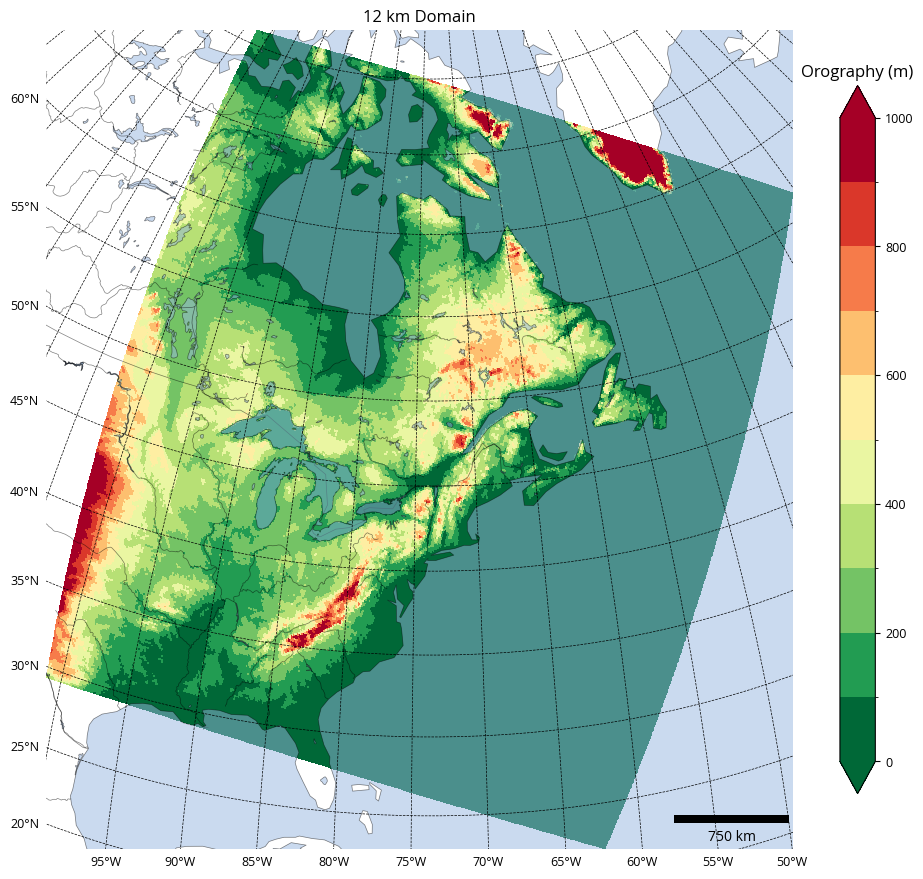

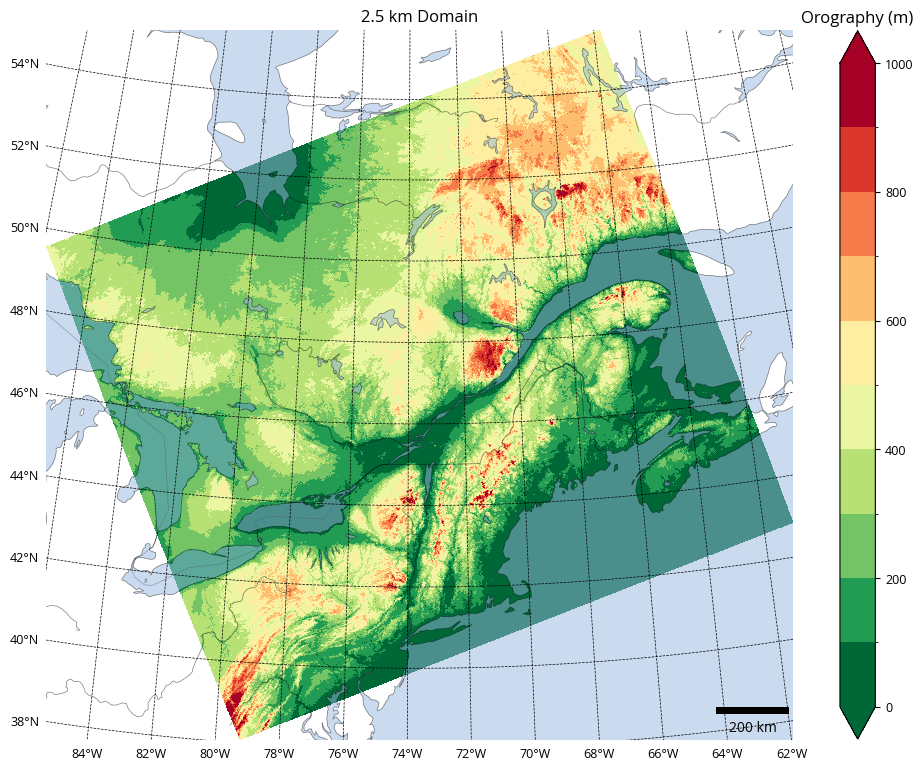

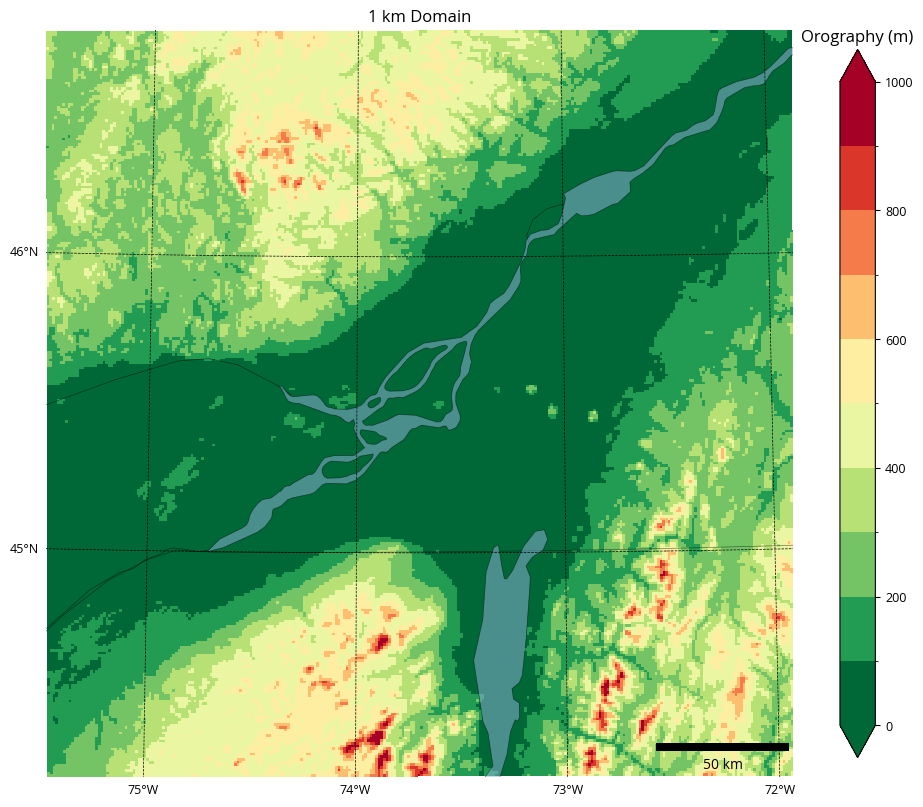

In [4]:
# Plot orography for large 12km free domain
fig,ax,cb = plot_field(domain_12km['orog'],domain='12km',
            cmap='RdYlGn_r',
            bins= [0,100,200,300,400,500,600,700,800,900,1000],
            # proj = projection,
            lat_lon_tick=5,extend='both',
            feature_colours='black',
            labelsize=9)
cb.ax.set_title('Orography (m)')
plt.title('12 km Domain')
plt.savefig(f'{path}/orog_12km_step1.png')

# Plot orography for medium 2.5km domain
fig,ax,cb = plot_field(domain_2p5km['orog'],domain='2.5km',
            cmap='RdYlGn_r',
            bins= [0,100,200,300,400,500,600,700,800,900,1000],
            # proj = projection,
            lat_lon_tick=2,extend='both',
            feature_colours='black',
            labelsize=9)
cb.ax.set_title('Orography (m)')                 
plt.title('2.5 km Domain')
plt.savefig(f'{path}/orog_2p5km_step2.png')

# Plot orography for small 1km domain using cartopy lake features
fig,ax,cb = plot_field(domain_1km['orog'],domain='2.5km', #placing domain 2.5km forces the use of Cartopy river/lake features
            cmap='RdYlGn_r',
            bins= [0,100,200,300,400,500,600,700,800,900,1000],
            # proj = projection,
            lat_lon_tick=1,extend='both',
            feature_colours='black',
            labelsize=9)
cb.ax.set_title('Orography (m)')
plt.title('1 km Domain')
plt.savefig(f'{path}/orog_1km_step3.png')

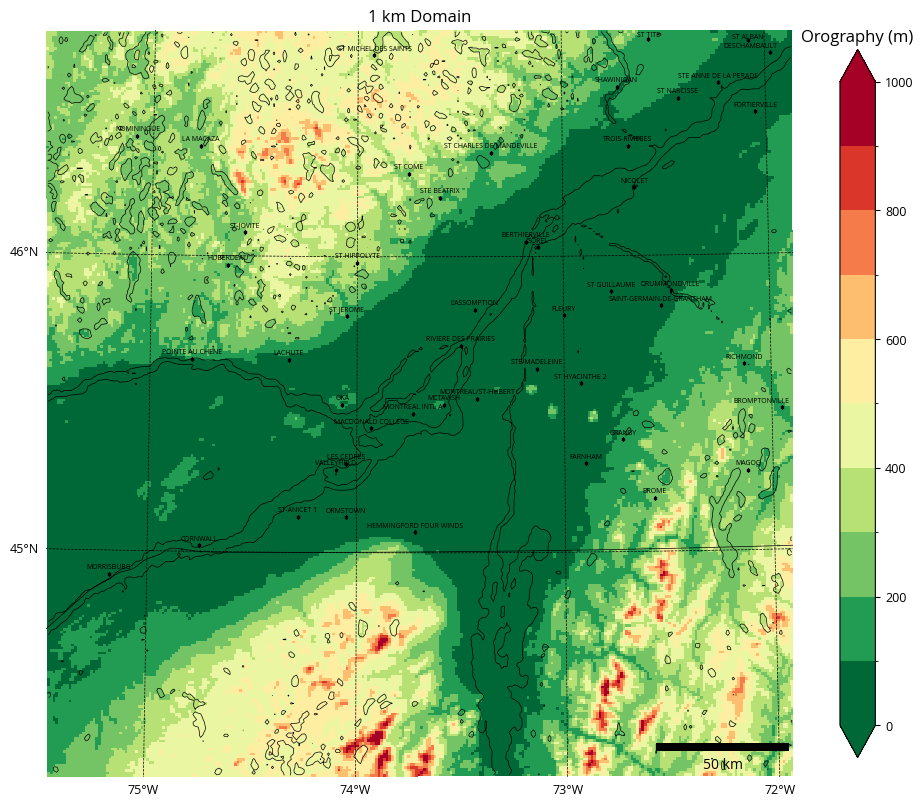

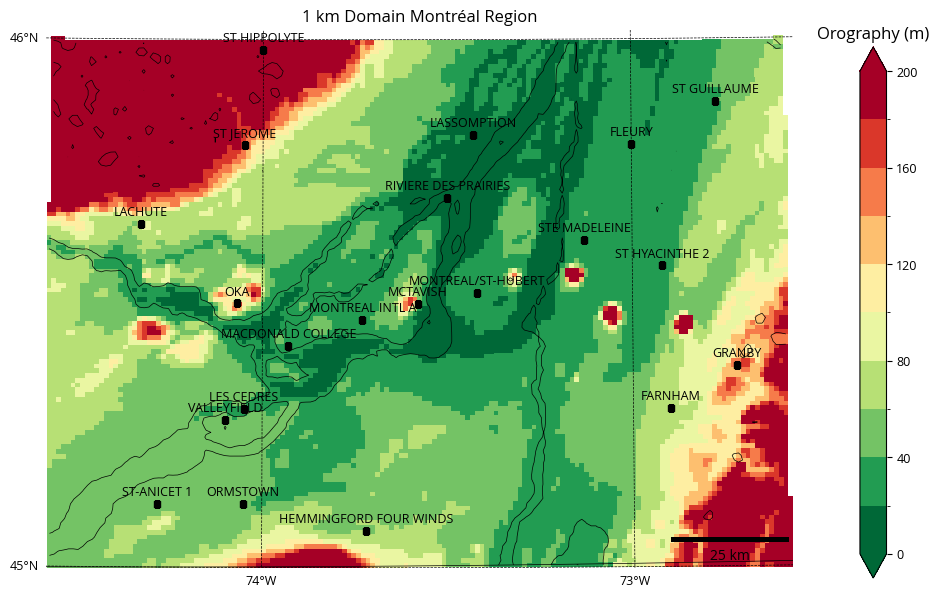

In [7]:
# Plot orography for small 1km domain using model lake features and transparent water
fig,ax,cb = plot_field(domain_1km['orog'],domain='1km', # without Cartopy river/lake features
            cmap='RdYlGn_r',
            bins= [0,100,200,300,400,500,600,700,800,900,1000],
            # proj = projection,
            lat_lon_tick=1,extend='both',
            feature_colours='black',
            labelsize=9)
# Include stations in the subdomain
station_set = stations
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black')
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=2,label=f'all stations ({len(station_set.station)})')
cb.ax.set_title('Orography (m)')
plt.title('1 km Domain')
plt.savefig(f'{path}/orog_stations_1km_step4.png')

# Zoom in on 1km domain to the Montréal region with stations
fig,ax,cb = plot_field(domain_1km['orog'],domain='1km',
            cmap='RdYlGn_r',
            bins= [0,20,40,60,80,100,120,140,160,180,200],
            MTL_focus=True,
            lat_lon_tick=1,extend='both',
            feature_colours='black',
            labelsize=9)
# Plot stations within the Montréal region
stations_mtl = stations.sel(station=station_is_near_montreal(stations))
station_set = stations_mtl #zoomed in
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black',features_fontsize=9)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'all stations ({len(station_set.station)})')
cb.ax.set_title('Orography (m)')

pos = cb.ax.get_position()
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
plt.title('1 km Domain Montréal Region')
plt.savefig(f'{path}/orog_stations_mtl_step5.png')

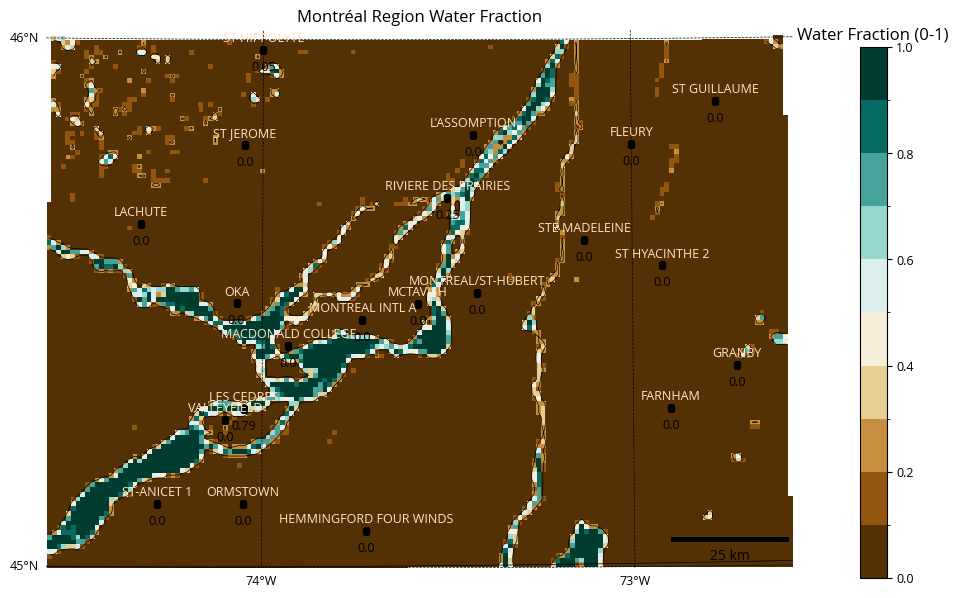

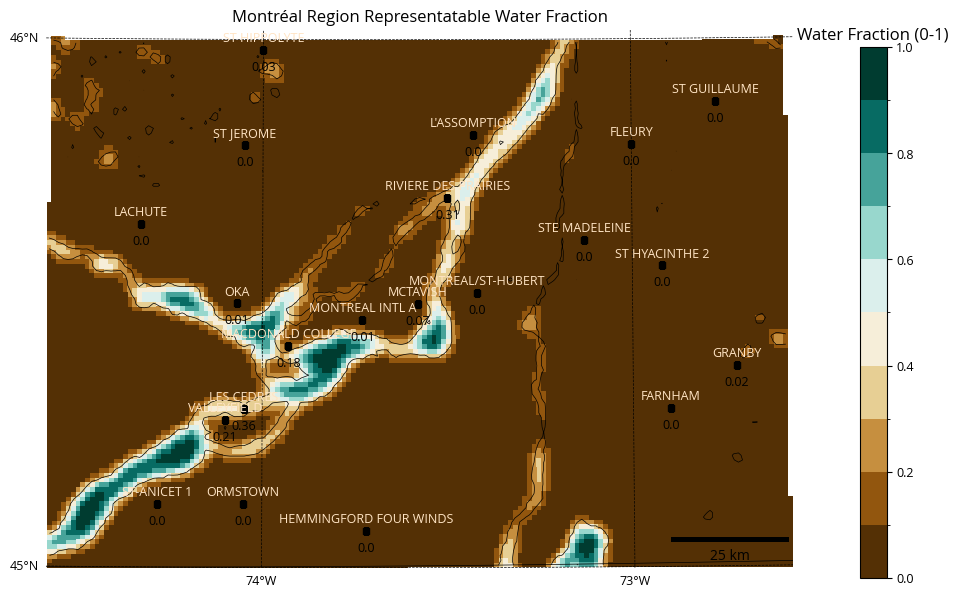

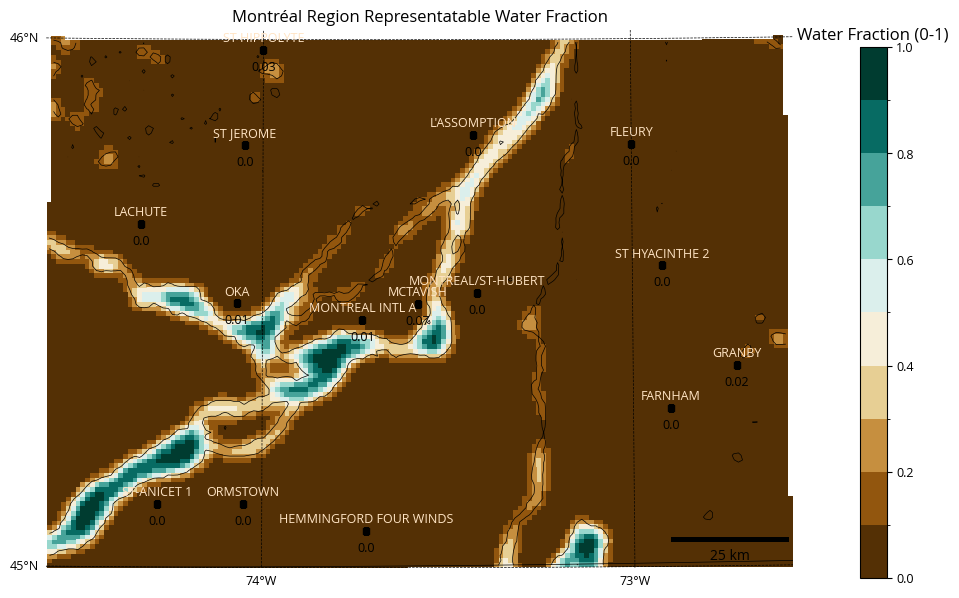

In [30]:
# Water fraction and station classification in the Montréal region
station_set = stations_mtl
field = lake_fraction

# Plot Montréal region lake fraction
fig,ax,cb = plot_field(field,domain='1km',
            cmap='BrBG',
            bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
            MTL_focus=True,
            lat_lon_tick=1,extend='neither',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='bisque',field=field,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'all stations ({len(station_set.station)})')

pos = cb.ax.get_position()
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Water Fraction (0-1)')
plt.title('Montréal Region Water Fraction')
plt.savefig(f'{path}/flake_step6.png')

# Plot Montréal region blurred lake fraction
field = gaussian_blur_xarray(lake_fraction)
fig,ax,cb = plot_field(field,domain='1km',
            cmap='BrBG',
            bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
            MTL_focus=True,
            lat_lon_tick=1,extend='neither',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='bisque',field=field,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'all stations ({len(station_set.station)})')

cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Water Fraction (0-1)')
plt.title('Montréal Region Representatable Water Fraction')
plt.savefig(f'{path}/flake_blurred_step7.png')

# Plot Montréal region blurred lake fraction this time remove stations with >10% water fraction
field = gaussian_blur_xarray(lake_fraction)
station_set = dry_stations_mtl # removed stations with >10% water fraction
fig,ax,cb = plot_field(field,domain='1km',
            cmap='BrBG',
            bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
            MTL_focus=True,
            lat_lon_tick=1,extend='neither',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='bisque',field=field,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'dry stations ({len(station_set.station)})')
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Water Fraction (0-1)')
plt.title('Montréal Region Representatable Water Fraction')
plt.savefig(f'{path}/flake_stationfilter_step8.png')


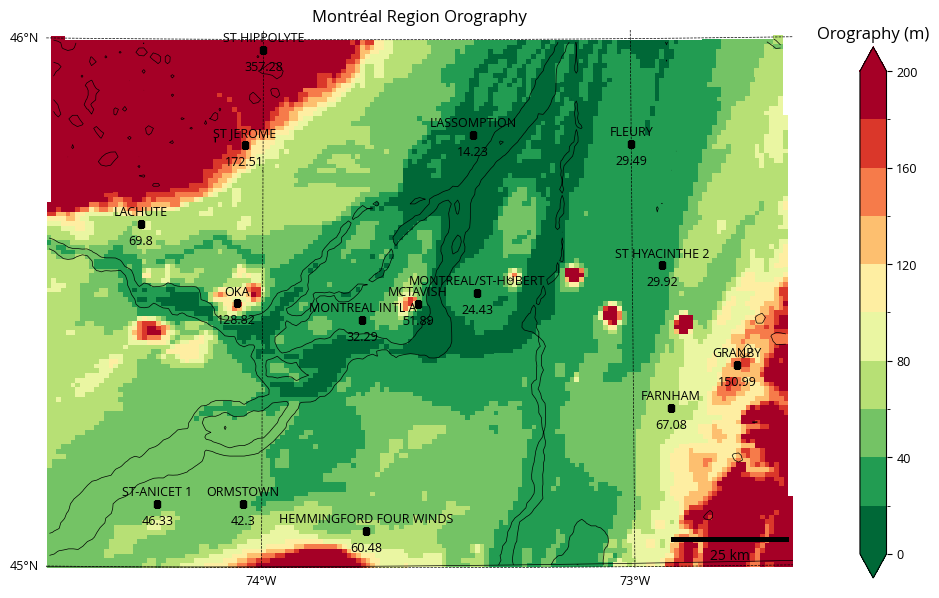

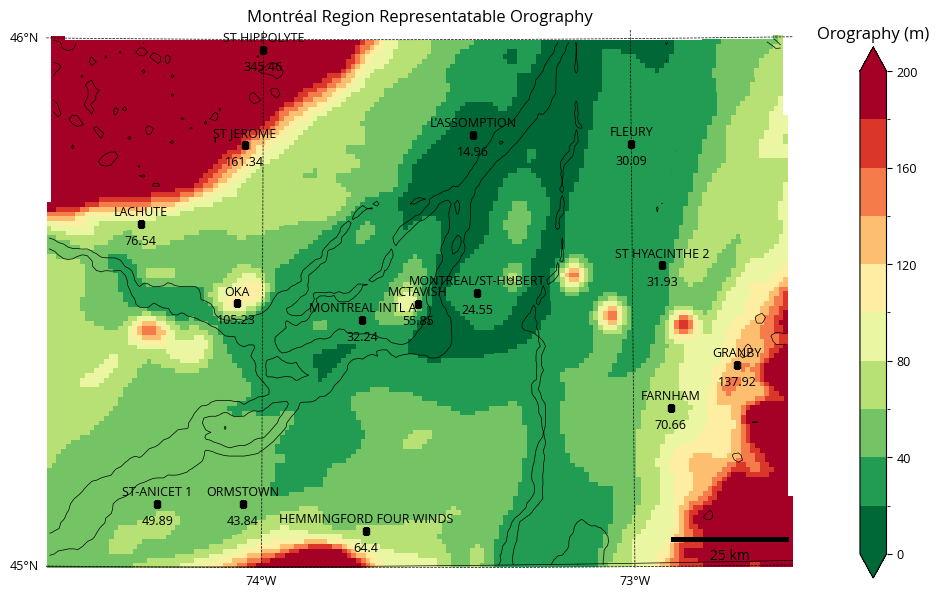

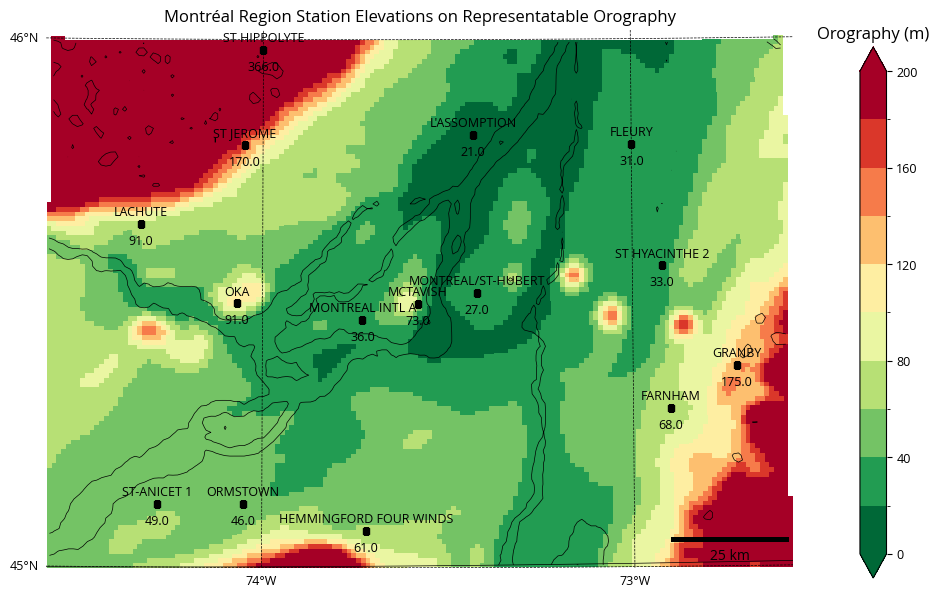

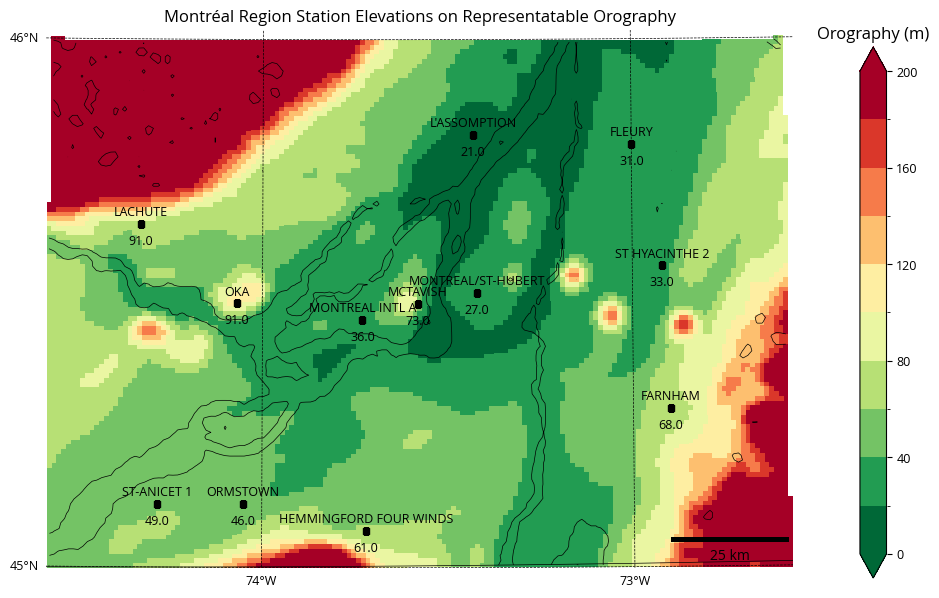

In [35]:
# Re-Plot Montréal region elevations with dry stations using better orography scale
field = domain_1km['orog']
station_set = dry_stations_mtl
fig,ax,cb = plot_field(field,domain='1km',
            cmap='RdYlGn_r',
            vmin=0,
            vmax=200,
            MTL_focus=True,
            lat_lon_tick=1,extend='both',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black',field=field,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'dry stations ({len(station_set.station)})')
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Water Fraction (0-1)')
cb.ax.set_title('Orography (m)')
plt.title('Montréal Region Orography')
plt.savefig(f'{path}/orog_step9.png')


# Plot Montréal region blurred elevations with dry stations
field = gaussian_blur_xarray(domain_1km['orog'])
station_set = dry_stations_mtl
fig,ax,cb = plot_field(field,domain='1km',
            cmap='RdYlGn_r',
            vmin=0,
            vmax=200,
            MTL_focus=True,
            lat_lon_tick=1,extend='both',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black',field=field,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'dry stations ({len(station_set.station)})')
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Water Fraction (0-1)')
cb.ax.set_title('Orography (m)')
plt.title('Montréal Region Representatable Orography')
plt.savefig(f'{path}/orog_blurred_step10.png')

# Plot Montréal region blurred orography with dry stations
field = gaussian_blur_xarray(domain_1km['orog'])
station_set = dry_stations_mtl
fig,ax,cb = plot_field(field,domain='1km',
            cmap='RdYlGn_r',
            vmin=0,
            vmax=200,
            MTL_focus=True,
            lat_lon_tick=1,extend='both',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black',linear_field=station_set.elev.values,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'dry stations ({len(station_set.station)})')
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Water Fraction (0-1)')
cb.ax.set_title('Orography (m)')
plt.title('Montréal Region Station Elevations on Representatable Orography')
plt.savefig(f'{path}/orog_blurred_stnelev_step11.png')

# Plot Montréal region blurred orography with obs
field = gaussian_blur_xarray(domain_1km['orog'])
station_set = obs
fig,ax,cb = plot_field(field,domain='1km',
            cmap='RdYlGn_r',
            vmin=0,
            vmax=200,
            MTL_focus=True,
            lat_lon_tick=1,extend='both',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black',linear_field=station_set.elev.values,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'dry stations ({len(station_set.station)})')
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Water Fraction (0-1)')
cb.ax.set_title('Orography (m)')
plt.title('Montréal Region Station Elevations on Representatable Orography')
plt.savefig(f'{path}/orog_blurred_stnelev_step12.png')


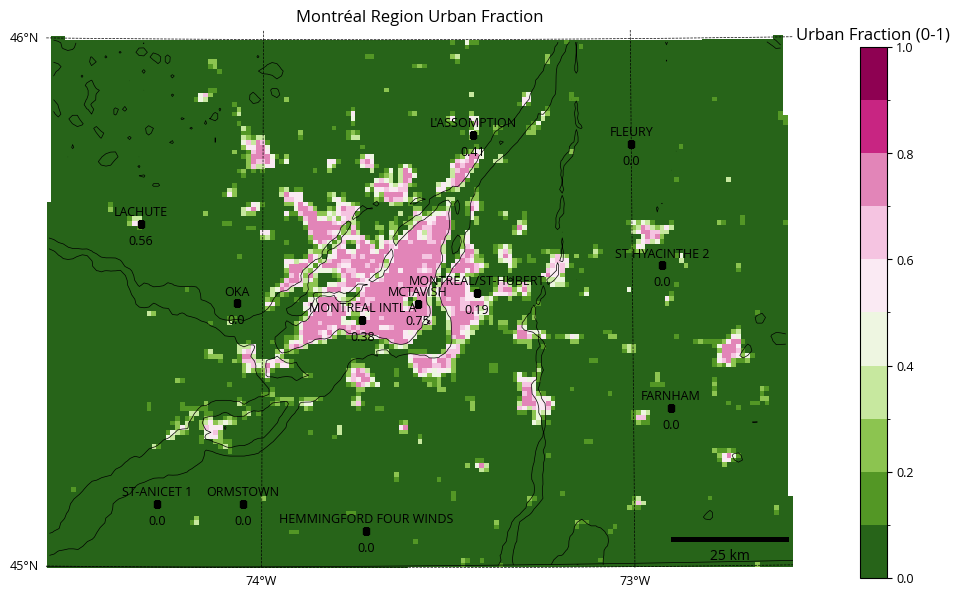

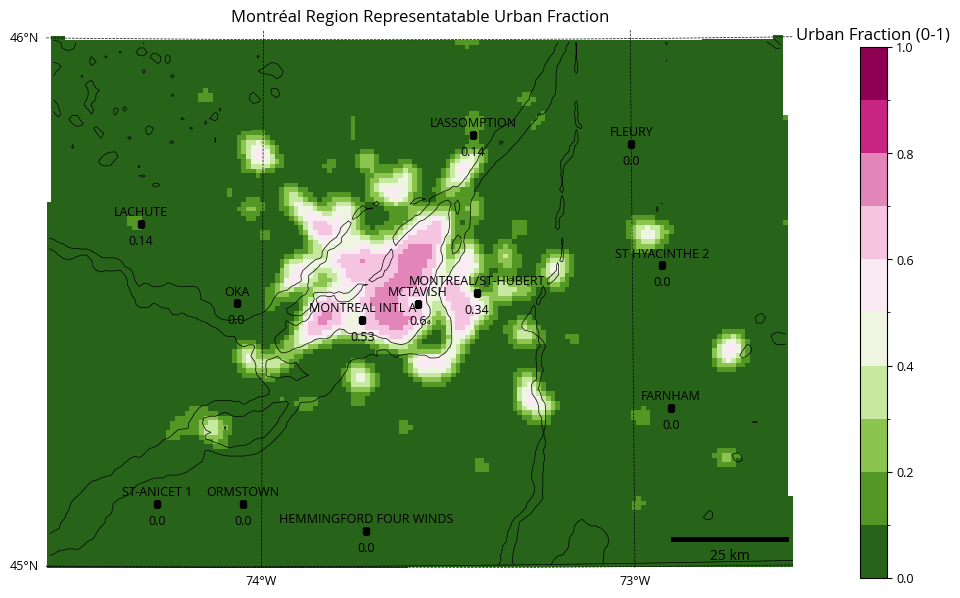

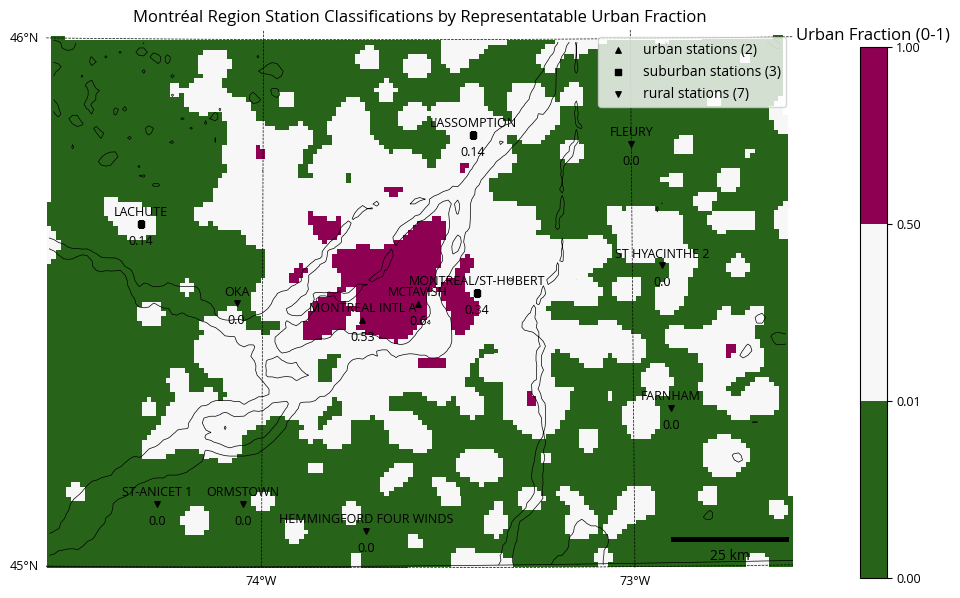

In [10]:
# Urban fraction and station classification in the Montréal region
station_set = obs
field = urban_fraction

# Plot Montréal region urban fraction
field = urban_fraction
fig,ax,cb = plot_field(field,domain='1km',
            cmap='PiYG_r',
            bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.],
            MTL_focus=True,
            lat_lon_tick=1,extend='neither',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black',field=field,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'all stations ({len(station_set.station)})')
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Urban Fraction (0-1)')
plt.title('Montréal Region Urban Fraction')
plt.savefig(f'{path}/furban_step13.png')
# plt.show()

# Plot Montréal region blurred urban fraction
field = blurred_urban_fraction
fig,ax,cb = plot_field(field,domain='1km',
            cmap='PiYG_r',
            bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.],
            MTL_focus=True,
            lat_lon_tick=1,extend='neither',
            feature_colours='black',
            labelsize=9)
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black',field=field,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'all stations ({len(station_set.station)})')
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Urban Fraction (0-1)')
plt.title('Montréal Region Representatable Urban Fraction')
plt.savefig(f'{path}/furban_blurred_step14.png')
# plt.show()

# Plot Montréal region blurred urban fraction and station classifications
field = blurred_urban_fraction
fig,ax,cb = plot_field(field,domain='1km',
            cmap='PiYG_r',
            bins = [0,0.01,0.5,1],
            MTL_focus=True,
            lat_lon_tick=1,extend='neither',
            feature_colours='black',
            labelsize=9,
            spacing='uniform')
plot_stations(fig=fig,ax=ax,station_set=station_set,features_colour='black',field=field,features_fontsize=9,field_fontcolour='black',field_fontsize=9,)
# ax.scatter(station_set.lon,station_set.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=2,label=f'all stations ({len(station_set.station)})')
ax.scatter(obs_urban.lon,obs_urban.lat,transform=ccrs.PlateCarree(),color='black', marker='^',s=15,label=f'urban stations ({len(obs_urban.station)})')
ax.scatter(obs_suburban.lon,obs_suburban.lat,transform=ccrs.PlateCarree(),color='black', marker='s',s=15,label=f'suburban stations ({len(obs_suburban.station)})')
ax.scatter(obs_rural.lon,obs_rural.lat,transform=ccrs.PlateCarree(),color='black', marker='v',s=15,label=f'rural stations ({len(obs_rural.station)})')
ax.legend()
cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])
cb.ax.set_title('Urban Fraction (0-1)')
plt.title('Montréal Region Station Classifications by Representatable Urban Fraction')
plt.savefig(f'{path}/furban_stnclass_step15.png')
# plt.show()
